In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../DataSet/ml_ready_data.csv')

In [3]:
df.drop(columns=['Seniority'], inplace=True)

In [ ]:
df

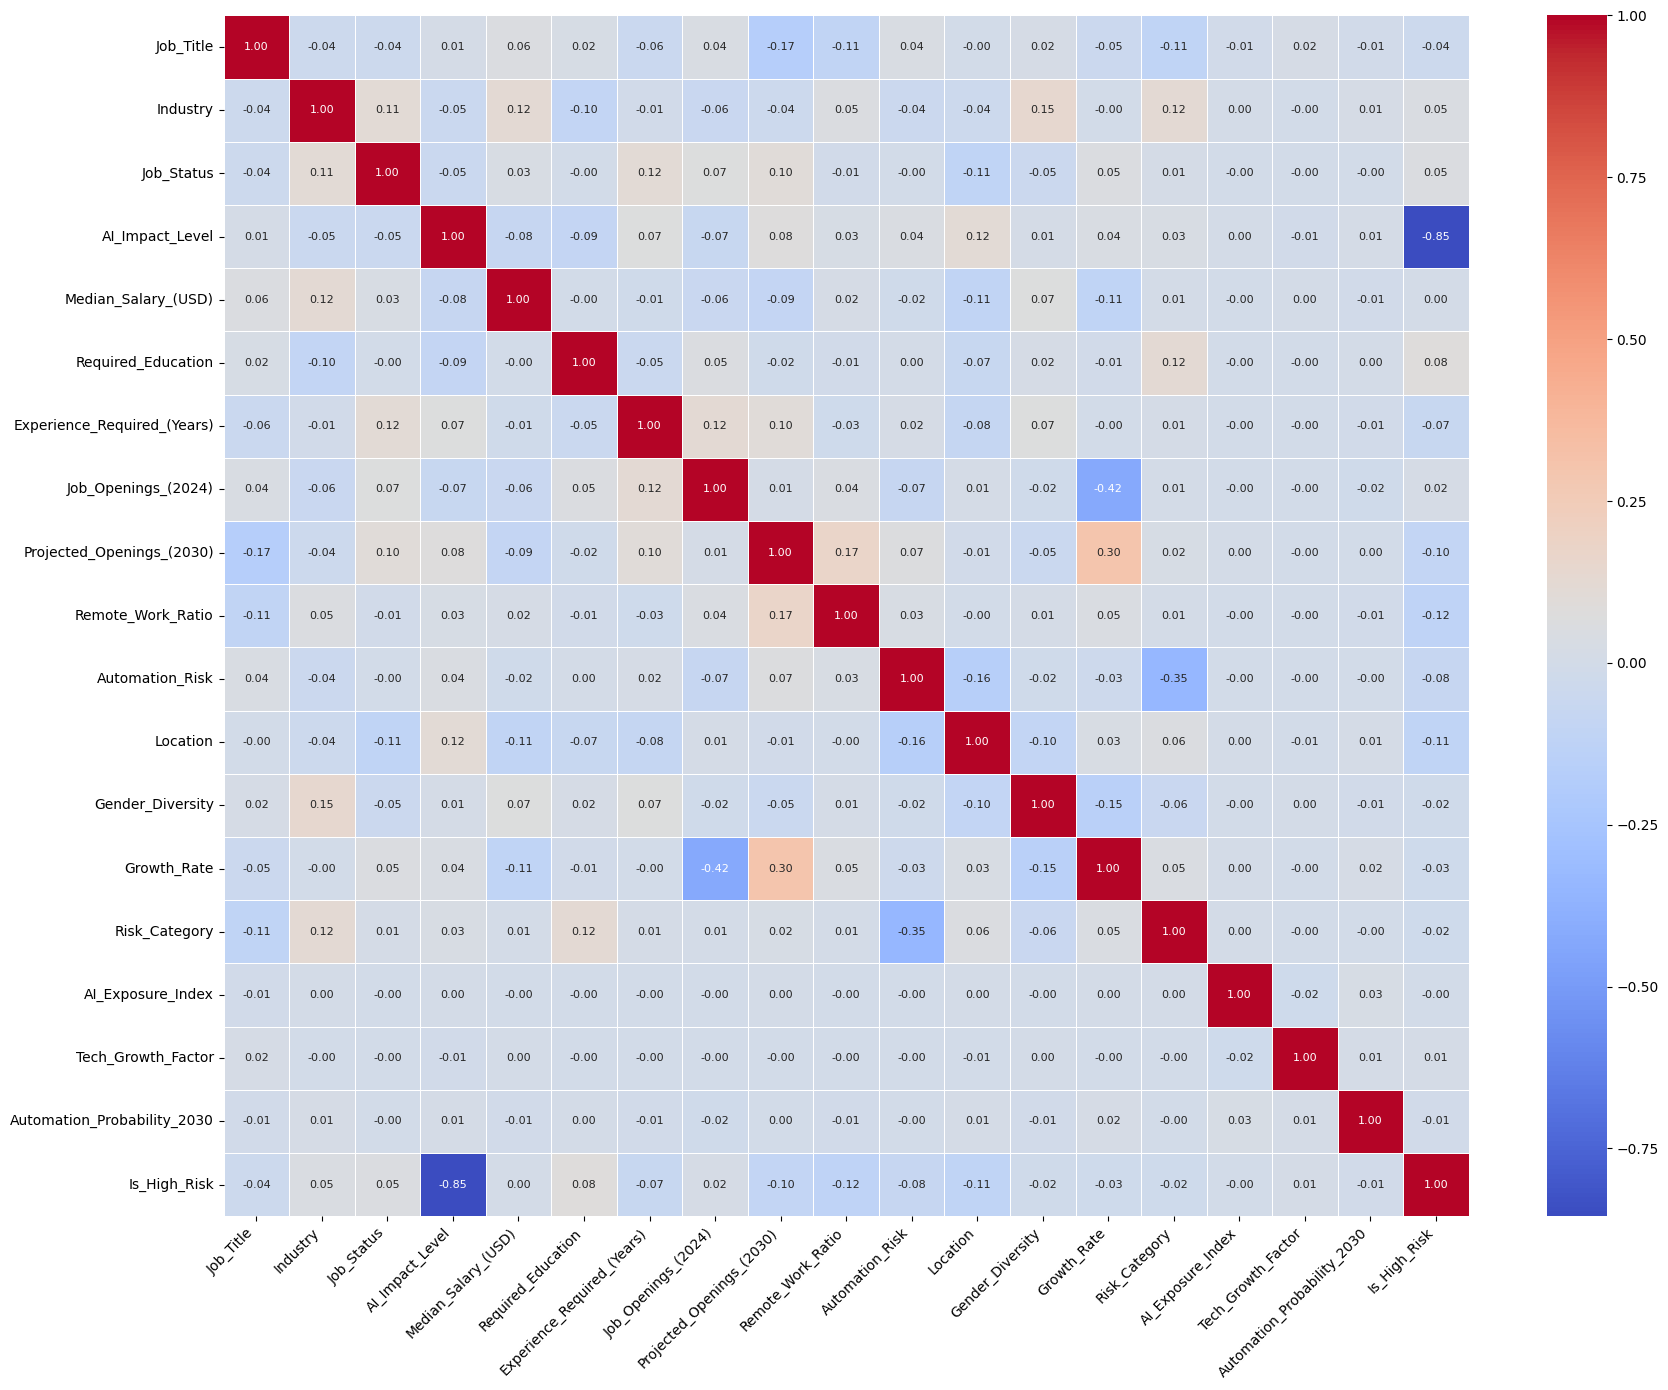

In [4]:
plt.figure(figsize=(18,14))

sns.heatmap(
df.corr(),
annot=True,
fmt=".2f",
cmap="coolwarm",
linewidths=0.5,
annot_kws={"size":8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [6]:
suspicious_columns = [
    'Is_High_Risk', 
    'Automation_Risk', 
    'Risk_Category', 
    'Automation_Probability_2030', 
    'AI_Exposure_Index',
]

In [7]:
features = df.drop(columns=['AI_Impact_Level'] + suspicious_columns, errors='ignore')
target = df['AI_Impact_Level']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(features ,target , test_size=0.2, random_state=42)

In [10]:
estimators_to_test = [50, 75, 100, 250, 300 ,400 ,500]

In [11]:
print("Starting Hyperparameter Tuning...\n")
for n in estimators_to_test:
    rf_model = RandomForestClassifier(
        n_estimators=n, 
        max_depth=4, 
        random_state=42, 
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Model with {n} Estimators -> Accuracy: {acc:.2f}%")
print("\nTuning Complete!")

Starting Hyperparameter Tuning...

Model with 50 Estimators -> Accuracy: 83.85%
Model with 75 Estimators -> Accuracy: 85.85%
Model with 100 Estimators -> Accuracy: 86.80%
Model with 250 Estimators -> Accuracy: 87.74%
Model with 300 Estimators -> Accuracy: 87.30%
Model with 400 Estimators -> Accuracy: 87.30%
Model with 500 Estimators -> Accuracy: 86.45%

Tuning Complete!


In [12]:
rf_model = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1 ,max_depth=4)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8774013272790779

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1926
           1       0.85      0.97      0.91      2537
           2       1.00      0.56      0.72      1263

    accuracy                           0.88      5726
   macro avg       0.91      0.83      0.85      5726
weighted avg       0.89      0.88      0.87      5726



In [ ]:


importance_df

NameError: name 'importance_df' is not defined

/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_8160/564730166.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma')


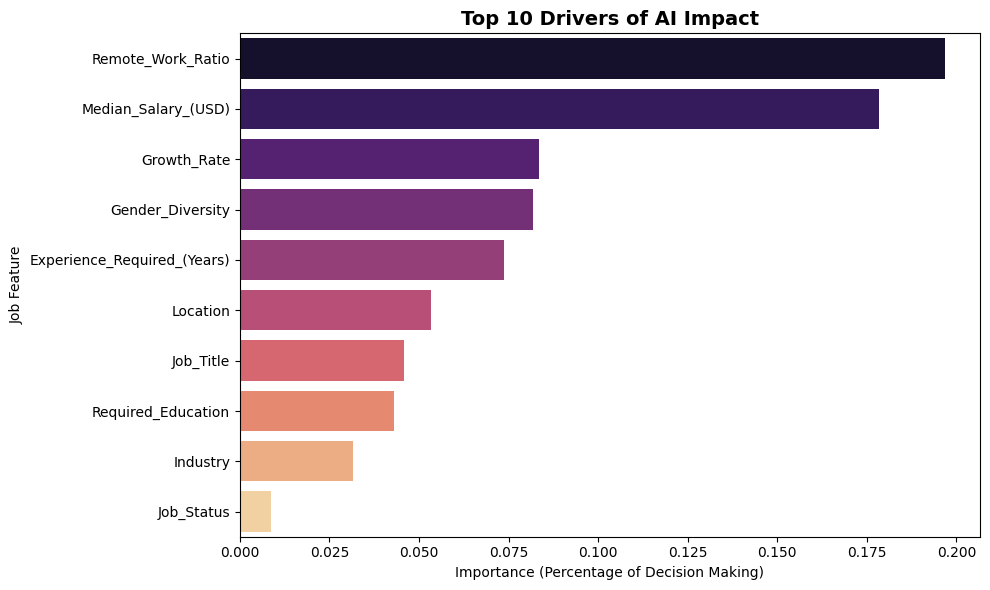

In [18]:

importances = rf_model.feature_importances_

feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
importance_df.drop(index=importance_df[importance_df['Feature'] == 'Projected_Openings_(2030)'].index, inplace=True) 
importance_df.drop(index=importance_df[importance_df['Feature'] == 'Job_Openings_(2024)'].index, inplace=True) 

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Drivers of AI Impact', fontsize=14, fontweight='bold')
plt.xlabel('Importance (Percentage of Decision Making)')
plt.ylabel('Job Feature')
plt.tight_layout()
plt.show()